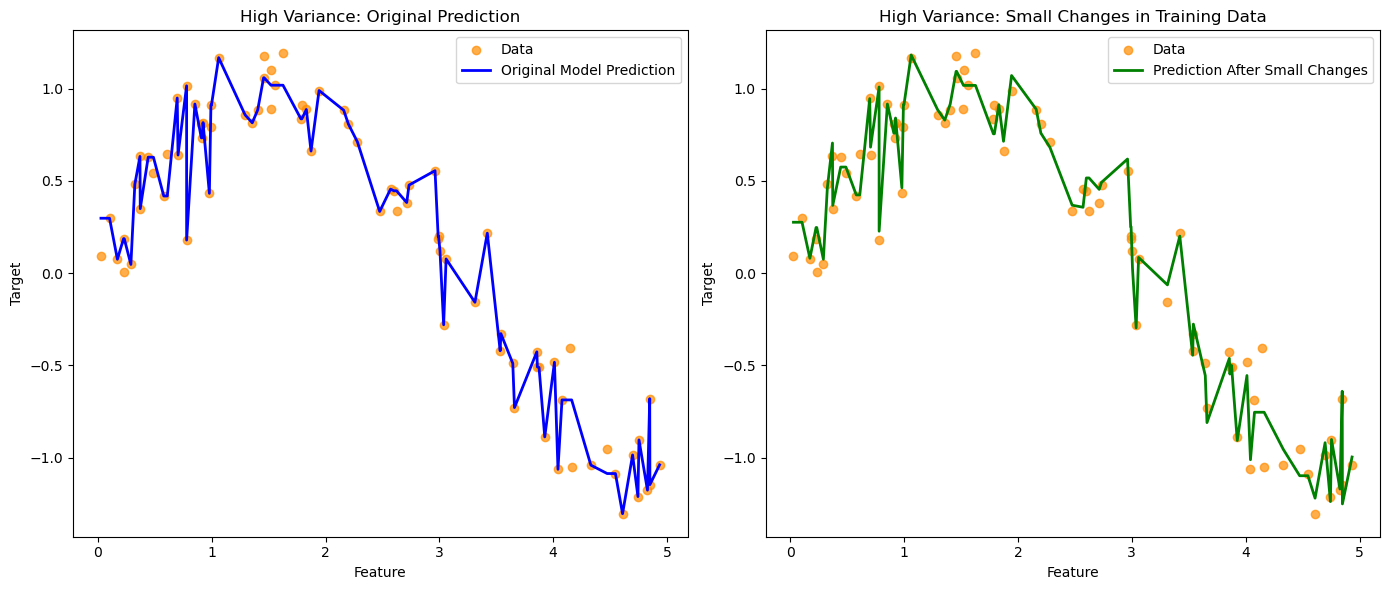

In [1]:
import numpy as np
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# Generate a simple dataset
np.random.seed(42)
X = np.sort(5 * np.random.rand(80, 1), axis=0)  # Features
y = np.sin(X).ravel() + np.random.normal(0, 0.2, X.shape[0])  # Add some noise

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create a Decision Tree Regressor with a very deep tree (high variance)
high_variance_model = DecisionTreeRegressor(max_depth=15, random_state=42)
high_variance_model.fit(X_train, y_train)

# Original Predictions
y_pred_original = high_variance_model.predict(X)

# Small changes in the training data
np.random.seed(24)
y_train_changed = y_train + np.random.normal(0, 0.05, y_train.shape[0])  # Slight noise change
high_variance_model_changed = DecisionTreeRegressor(max_depth=15, random_state=42)
high_variance_model_changed.fit(X_train, y_train_changed)

# Predictions with small changes
y_pred_changed = high_variance_model_changed.predict(X)

# Plot the original prediction
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.scatter(X, y, color="darkorange", label="Data", alpha=0.7)
plt.plot(X, y_pred_original, color="blue", label="Original Model Prediction", linewidth=2)
plt.title("High Variance: Original Prediction")
plt.xlabel("Feature")
plt.ylabel("Target")
plt.legend()

# Plot the prediction with small changes
plt.subplot(1, 2, 2)
plt.scatter(X, y, color="darkorange", label="Data", alpha=0.7)
plt.plot(X, y_pred_changed, color="green", label="Prediction After Small Changes", linewidth=2)
plt.title("High Variance: Small Changes in Training Data")
plt.xlabel("Feature")
plt.ylabel("Target")
plt.legend()

plt.tight_layout()
plt.show()
